# Análisis exploratorio de comisiones por bloque de Bitcoin

Cada fila del dataset representa un **bloque**. El proyecto busca clasificar la tasa mediana de comisión del siguiente bloque como **alta** o **no alta**.

Este análisis revisa la estructura de los datos, su calidad, las distribuciones y sus relaciones. No se entrenan modelos.

Fuente: Jesús Graterol, [Bitcoin Blockchain Historical Data](https://www.kaggle.com/datasets/jesusgraterol/bitcoin-blockchain-dataset), Kaggle.

## 1. Importar las librerías

Pandas permite trabajar con tablas y Matplotlib crear gráficos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## 2. Cargar y observar el dataset

El notebook y `dataset.csv` están en la misma carpeta. Se ejecuta desde `eda/`.


In [2]:
df = pd.read_csv("dataset.csv")
df.head()


,height,timestamp,size,tx_count,difficulty,median_fee_rate,avg_fee_rate,total_fees,fee_range_min,fee_range_max,input_count,output_count,output_amount
0,1,1231469665000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
1,2,1231469744000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
2,3,1231470173000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
3,4,1231470988000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0
4,5,1231471428000,215,1,1.0,0.0,0,0,0.0,0.0,0,1,0


In [3]:
print("Filas y columnas:", df.shape)
df.info()


Filas y columnas: (810909, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810909 entries, 0 to 810908
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   height           810909 non-null  int64  
 1   timestamp        810909 non-null  int64  
 2   size             810909 non-null  int64  
 3   tx_count         810909 non-null  int64  
 4   difficulty       810909 non-null  float64
 5   median_fee_rate  810909 non-null  float64
 6   avg_fee_rate     810909 non-null  int64  
 7   total_fees       810909 non-null  int64  
 8   fee_range_min    810909 non-null  float64
 9   fee_range_max    810909 non-null  float64
 10  input_count      810909 non-null  int64  
 11  output_count     810909 non-null  int64  
 12  output_amount    810909 non-null  int64  
dtypes: float64(4), int64(9)
memory usage: 80.4 MB


### ¿Qué significa cada columna?

| Columna | Significado |
|---|---|
| `height` | Altura: posición del bloque en la cadena |
| `timestamp` | Fecha del bloque, como timestamp Unix en milisegundos |
| `size` | Tamaño del bloque en bytes |
| `tx_count` | Cantidad de transacciones del bloque |
| `difficulty` | Dificultad de minería |
| `median_fee_rate` | Tasa mediana de comisión publicada |
| `avg_fee_rate` | Tasa promedio de comisión publicada |
| `total_fees` | Comisiones totales del bloque, en satoshis |
| `fee_range_min` | Tasa mínima publicada |
| `fee_range_max` | Tasa máxima publicada |
| `input_count` | Cantidad agregada de entradas |
| `output_count` | Cantidad agregada de salidas |
| `output_amount` | Valor agregado de salidas, en satoshis |

Las tasas se analizan en la escala publicada. Falta verificar su unidad y definición históricas exactas con la fuente; no se sustituyen por `total_fees / size`. Las entradas y salidas no representan personas únicas.

## 3. Valores faltantes y duplicadoss

Estas revisiones iniciales describen la calidad del archivo completo.


In [4]:
df.isna().sum()

height             0
timestamp          0
size               0
tx_count           0
difficulty         0
median_fee_rate    0
avg_fee_rate       0
total_fees         0
fee_range_min      0
fee_range_max      0
input_count        0
output_count       0
output_amount      0
dtype: int64

In [5]:
print("Filas duplicadas:", df.duplicated().sum())
print("Alturas repetidas:", df["height"].duplicated().sum())
print("Valores negativos por columna:")
df.lt(0).sum()

Filas duplicadas: 0
Alturas repetidas: 0
Valores negativos por columna:


height             0
timestamp          0
size               0
tx_count           0
difficulty         0
median_fee_rate    0
avg_fee_rate       0
total_fees         0
fee_range_min      0
fee_range_max      0
input_count        0
output_count       0
output_amount      0
dtype: int64

En esta copia no se encontraron nulos, duplicados ni valores negativos. Por ello, no se necesita rellenar datos ni eliminar filas por esos motivos. Esto no garantiza que todas las mediciones estén libres de problemas.

## 4. Ordenar los bloques y reservar los datos futuros

Se ordena por `height`. Las fechas registradas pueden retroceder entre bloques consecutivos; no representan tiempos de espera de una transacción.


In [6]:
df = df.sort_values("height").reset_index(drop=True)

print("Saltos de altura distintos de 1:", df["height"].diff().dropna().ne(1).sum())
print("Retrocesos del timestamp:", df["timestamp"].diff().lt(0).sum())

assert df["height"].diff().dropna().eq(1).all()


Saltos de altura distintos de 1: 0
Retrocesos del timestamp: 14572


Para cada bloque se toma la tasa del siguiente con `shift(-1)`. La última fila no tiene un bloque siguiente observado, así que se excluye de los pares.

Se respeta la propuesta: 70 % de entrenamiento, 15 % de validación y 15 % de prueba, sin mezclar el orden. A partir de aquí, el EDA utiliza **solo entrenamiento**. Las revisiones anteriores del archivo completo fueron estructurales; ya se hicieron inspecciones preliminares durante la formulación de la propuesta.


In [7]:
df["tasa_siguiente"] = df["median_fee_rate"].shift(-1)
datos = df.iloc[:-1].copy()

corte_train = int(len(datos) * 0.70)
corte_val = int(len(datos) * 0.85)

train = datos.iloc[:corte_train].copy()
validacion = datos.iloc[corte_train:corte_val].copy()
prueba = datos.iloc[corte_val:].copy()

print("Pares de entrenamiento:", len(train))
print("Pares de validación:", len(validacion))
print("Pares de prueba:", len(prueba))


Pares de entrenamiento: 567635
Pares de validación: 121636
Pares de prueba: 121637


## 5. Estadísticas descriptivas

`describe()` muestra cantidad, media, desviación estándar, mínimo, cuartiles y máximo. Las tasas y comisiones tienen valores máximos muy alejados de su mediana; conviene revisar esa asimetría en los gráficos.


In [8]:
columnas = ["size", "tx_count", "median_fee_rate", "avg_fee_rate",
            "total_fees", "fee_range_min", "fee_range_max",
            "input_count", "output_count", "output_amount", "difficulty"]

train[columnas].describe().T

,count,mean,std,min,25%,50%,75%,max
size,567635.0,3.687055e+05,4.306640e+05,176.0,5.049500e+03,1.453410e+05,8.424725e+05,2.377364e+06
tx_count,567635.0,6.919078e+02,8.763370e+02,1.0,1.300000e+01,2.560000e+02,1.141000e+03,1.223900e+04
median_fee_rate,567635.0,6.612199e+01,1.434225e+03,0.0,0.000000e+00,1.700000e+01,5.500000e+01,1.029502e+06
avg_fee_rate,567635.0,1.174955e+02,2.244237e+03,0.0,9.000000e+00,3.500000e+01,1.090000e+02,1.143052e+06
total_fees,567635.0,3.321916e+07,1.055646e+08,0.0,4.000000e+05,7.254490e+06,2.665175e+07,2.915328e+10
fee_range_min,567635.0,1.164529e+01,1.757091e+02,0.0,0.000000e+00,0.000000e+00,1.000000e+00,5.615500e+04
fee_range_max,567635.0,2.706347e+03,1.015376e+05,0.0,1.930000e+02,4.850000e+02,1.937000e+03,4.933333e+07
input_count,567635.0,1.740387e+03,2.048662e+03,0.0,2.100000e+01,6.960000e+02,3.769000e+03,2.089400e+04
output_count,567635.0,1.861437e+03,2.466487e+03,1.0,2.500000e+01,6.630000e+02,3.198000e+03,2.364200e+04
output_amount,567635.0,8.816447e+11,3.780498e+12,0.0,3.690000e+10,3.055187e+11,9.822967e+11,6.499324e+14


## 6. Distribuciones

Los histogramas permiten observar dónde se concentran los valores. Primero se revisan el tamaño y la cantidad de transacciones.


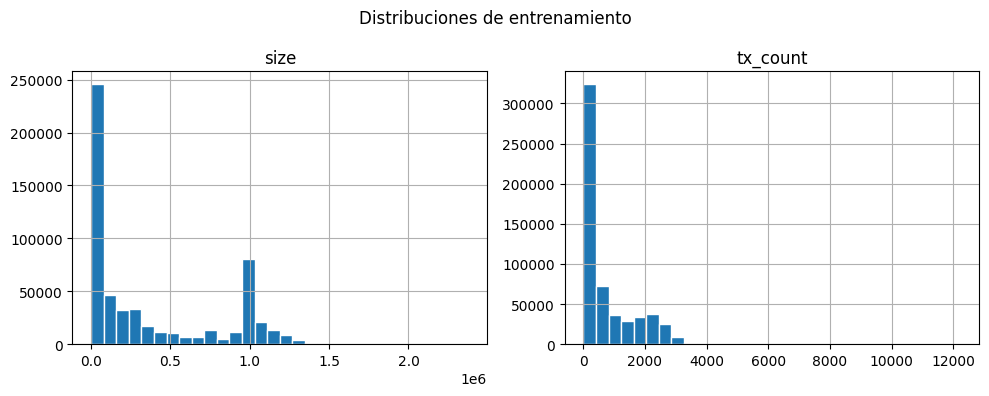

In [9]:
train[["size", "tx_count"]].hist(bins=30, figsize=(10, 4), edgecolor="white")
plt.suptitle("Distribuciones de entrenamiento")
plt.tight_layout()
plt.show()


La tasa mediana se grafica en su escala original para observar el efecto de los valores extremos.


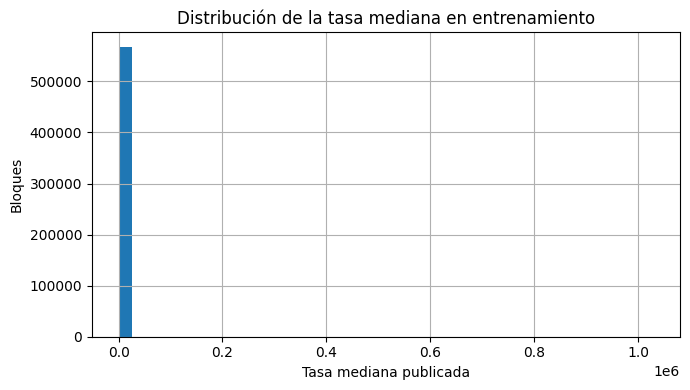

In [10]:
train["median_fee_rate"].hist(bins=40, figsize=(7, 4))
plt.xlabel("Tasa mediana publicada")
plt.ylabel("Bloques")
plt.title("Distribución de la tasa mediana en entrenamiento")
plt.tight_layout()
plt.show()


Unos pocos valores muy grandes extienden el eje horizontal y comprimen la mayor parte de los datos a la izquierda. Esto indica que hay que revisar los extremos; no justifica eliminarlos.

## 7. Tasas cero y bloques con una transacción

Un bloque con `tx_count = 1` contiene solo la transacción coinbase. No se elimina por ese motivo. Se comprueba si también hay tasas cero en bloques con más transacciones.


In [11]:
print("Bloques con una transacción:", (train["tx_count"] == 1).sum())
print("Bloques con tasa mediana cero:", (train["median_fee_rate"] == 0).sum())

con_varias_transacciones = train["tx_count"] > 1
con_tasa_cero = train["median_fee_rate"] == 0
print("Más de una transacción y tasa cero:", (con_varias_transacciones & con_tasa_cero).sum())

Bloques con una transacción: 88628
Bloques con tasa mediana cero: 177561
Más de una transacción y tasa cero: 88933


Existen bloques con varias transacciones y tasa mediana cero. Por eso, una tasa cero no identifica por sí sola un bloque con solo coinbase. Se conservan ambos casos; cero no se trata automáticamente como dato faltante.

## 8. Boxplots y valores extremos

El boxplot permite observar la mediana, la dispersión y los valores alejados del resto.


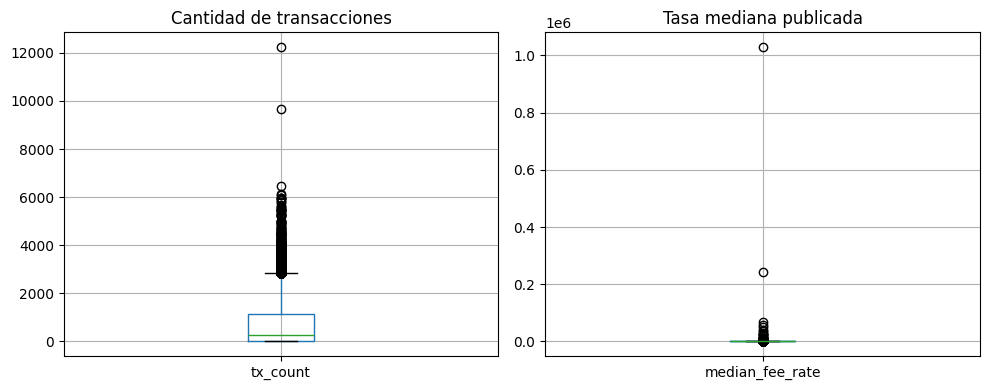

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train.boxplot(column="tx_count", ax=axes[0])
axes[0].set_title("Cantidad de transacciones")

train.boxplot(column="median_fee_rate", ax=axes[1])
axes[1].set_title("Tasa mediana publicada")

plt.tight_layout()
plt.show()

Se usa la regla del rango intercuartílico: `IQR = Q3 - Q1`. Los valores fuera de `Q1 - 1.5 × IQR` y `Q3 + 1.5 × IQR` se marcan para revisión, pero no se eliminan automáticamente.


In [13]:
q1 = train["median_fee_rate"].quantile(0.25)
q3 = train["median_fee_rate"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

extremos = train[(train["median_fee_rate"] < limite_inferior) |
                 (train["median_fee_rate"] > limite_superior)]

print("Límites IQR:", limite_inferior, limite_superior)
print("Bloques marcados:", len(extremos))
print("Porcentaje:", round(len(extremos) / len(train) * 100, 2))
extremos[["height", "median_fee_rate", "tx_count"]].nlargest(5, "median_fee_rate")

Límites IQR: -82.5 137.5
Bloques marcados: 54511
Porcentaje: 9.6


,height,median_fee_rate,tx_count
164383,164384,1029502.0,15
2816,2817,241545.0,4
71041,71042,68042.0,5
48889,48890,56155.0,2
164382,164383,50932.0,15


La regla marca 54 511 bloques de entrenamiento (9,60 %). Un extremo puede ser un dato real o una particularidad de la medición. Se conserva hasta contar con evidencia para corregirlo.

## 9. Variable objetivo y balance de clases

El percentil 75 de las tasas del siguiente bloque en entrenamiento define el umbral. Si la tasa supera ese valor, la clase es **1: alta**; en otro caso es **0: no alta**. La igualdad con el umbral pertenece a la clase 0.


In [14]:
umbral = train["tasa_siguiente"].quantile(0.75)
train["clase"] = (train["tasa_siguiente"] > umbral).astype(int)

print("Umbral:", umbral)
train[["height", "median_fee_rate", "tasa_siguiente", "clase"]].head()

Umbral: 55.0


,height,median_fee_rate,tasa_siguiente,clase
0,1,0.0,0.0,0
1,2,0.0,0.0,0
2,3,0.0,0.0,0
3,4,0.0,0.0,0
4,5,0.0,0.0,0


Porcentaje por clase:
clase
0    75.02
1    24.98
Name: count, dtype: float64


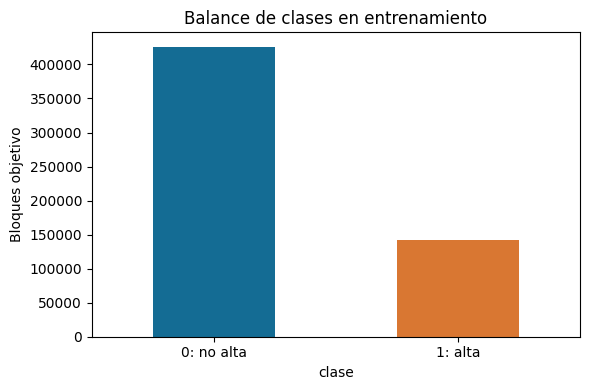

In [15]:
conteos = train["clase"].value_counts().sort_index()
porcentajes = conteos / len(train) * 100

print("Porcentaje por clase:")
print(porcentajes.round(2))

conteos.plot.bar(figsize=(6, 4), rot=0, color=["#146C94", "#D97732"])
plt.xticks([0, 1], ["0: no alta", "1: alta"])
plt.ylabel("Bloques objetivo")
plt.title("Balance de clases en entrenamiento")
plt.tight_layout()
plt.show()


El umbral es 55 en la escala publicada. La clase alta representa el 24,98 % de entrenamiento. Hay desbalance: predecir siempre «no alta» no demostraría que se identifican los bloques de comisión alta. Este mismo umbral se aplicará a validación y prueba durante el modelado.

## 10. Relaciones entre variables

Se utiliza la correlación de Pearson. Las entradas corresponden al bloque actual; `tasa_siguiente` corresponde al futuro y se incluye aquí solo para explorar su relación, nunca como entrada del modelo.


In [16]:
variables = ["size", "tx_count", "median_fee_rate", "total_fees", "tasa_siguiente"]
correlacion = train[variables].corr()
correlacion.round(3)


,size,tx_count,median_fee_rate,total_fees,tasa_siguiente
size,1.000,0.909,0.004,0.365,0.003
tx_count,0.909,1.000,0.008,0.393,0.005
median_fee_rate,0.004,0.008,1.000,0.179,0.050
total_fees,0.365,0.393,0.179,1.000,0.052
tasa_siguiente,0.003,0.005,0.050,0.052,1.000


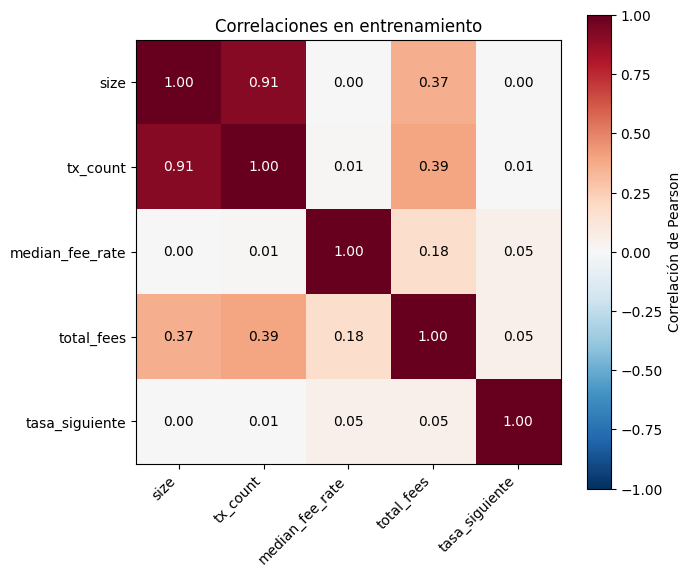

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
imagen = ax.imshow(correlacion, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(variables)), variables, rotation=45, ha="right")
ax.set_yticks(range(len(variables)), variables)

for i in range(len(variables)):
    for j in range(len(variables)):
        valor = correlacion.iloc[i, j]
        color = "white" if abs(valor) > 0.6 else "black"
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color=color)

fig.colorbar(imagen, ax=ax, label="Correlación de Pearson")
ax.set_title("Correlaciones en entrenamiento")
plt.tight_layout()
plt.show()


La correlación lineal entre la tasa actual y la siguiente es aproximadamente 0,05. Una correlación baja no descarta relaciones no lineales ni demuestra que el problema sea impredecible. Los extremos también pueden afectar Pearson.

Un diagrama de dispersión complementa la tabla. Se toma una muestra reproducible de 2 000 pares solo para facilitar la visualización; las estadísticas anteriores usan todo entrenamiento.


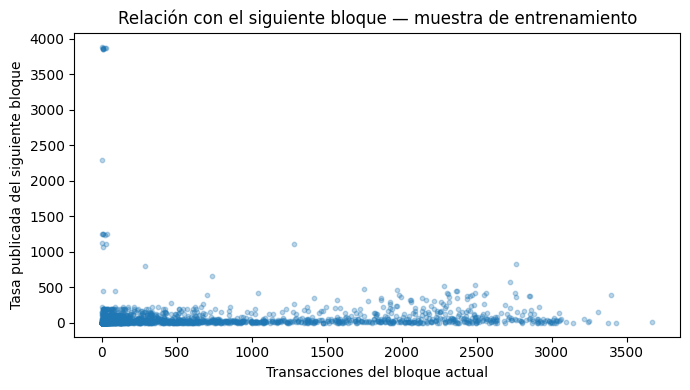

In [18]:
muestra = train.sample(2000, random_state=42)

plt.figure(figsize=(7, 4))
plt.scatter(muestra["tx_count"], muestra["tasa_siguiente"], s=10, alpha=0.3)
plt.xlabel("Transacciones del bloque actual")
plt.ylabel("Tasa publicada del siguiente bloque")
plt.title("Relación con el siguiente bloque — muestra de entrenamiento")
plt.tight_layout()
plt.show()


Las asociaciones observadas son descriptivas. No permiten atribuir causalidad ni anticipar el rendimiento de un clasificador. La evaluación de modelos se desarrollará posteriormente.


## 11. Evolución de las tasas por año

Se convierte `timestamp` a fecha, se obtiene el año y se agrupan los bloques de **entrenamiento**. Para cada año se calcula la mediana de `median_fee_rate`.

El resultado es la **mediana anual de las tasas publicadas por bloque**, no la mediana de todas las transacciones del año. La columna `bloques` indica cuántas observaciones aporta cada periodo.

Entrenamiento termina en marzo de 2019: ese año está incompleto. Validación y prueba no se utilizan en este gráfico.


In [19]:
anio = pd.to_datetime(train["timestamp"], unit="ms", utc=True).dt.year

evolucion_anual = train.groupby(anio)["median_fee_rate"].agg(["count", "median"])
evolucion_anual.columns = ["bloques", "mediana_tasa"]
evolucion_anual.index.name = "anio"

evolucion_anual


,bloques,mediana_tasa
anio,,
2009,32489,0.0
2010,67920,0.0
2011,59627,0.0
2012,54526,59.0
2013,63433,76.0
2014,58865,20.0
2015,54321,19.0
2016,54851,39.0
2017,55928,134.0


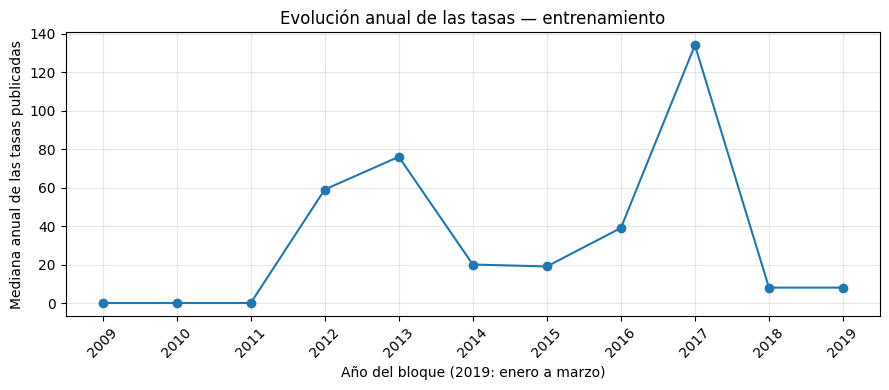

In [20]:
evolucion_anual["mediana_tasa"].plot(figsize=(9, 4), marker="o")
plt.xticks(evolucion_anual.index, rotation=45)
plt.xlabel("Año del bloque (2019: enero a marzo)")
plt.ylabel("Mediana anual de las tasas publicadas")
plt.title("Evolución anual de las tasas — entrenamiento")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


La mediana anual alcanza 134 en 2017 y baja a 8 en 2018, en la escala del dataset. Las tasas no mantienen el mismo nivel durante todo el periodo; esto respalda conservar el orden temporal al evaluar el modelo.

Una mediana anual de cero no significa que todos los bloques de ese año tengan tasa cero. Además, el gráfico describe cambios observados: por sí solo no explica sus causas ni predice el siguiente bloque.


## Referencias

- Jesús Graterol. [Bitcoin Blockchain Historical Data](https://www.kaggle.com/datasets/jesusgraterol/bitcoin-blockchain-dataset), Kaggle.
- Jesús Graterol. [Generador y esquema del dataset](https://github.com/jesusgraterol/bitcoin-blockchain-dataset-builder).
- Bitcoin Developer Documentation. [Block Chain](https://developer.bitcoin.org/reference/block_chain.html), transacción coinbase.
